In [2]:
import numpy as np
import matplotlib.pyplot as plt

with open("elevationdata.txt", "r") as file:
    lines = file.readlines()

# Initialize an array of zeros with the number of rows and 3 columns
data = np.zeros((len(lines), 3))

# Populate the array with the data from each line
for i, row in enumerate(lines):
    for k,j in enumerate(row.split()):
        #print(float(j))
        data[i,k] = float(j)  # Convert each element to float
#print(data)

x = np.unique(data[:, 0])
y = np.unique(data[:, 1])
#print(x,y)
# Create a meshgrid for X and Y
X, Y = np.meshgrid(x, y)

Z = np.empty((len(y), len(x)))
# Reshape Z values to match the shape of X and Y grids
for i, row in enumerate(lines):
    #if float(row.split()[2]) > -2000:
    #print(row[2])
    Z[np.where(y == data[i, 1])[0][0], np.where(x == data[i, 0])[0][0]] = row.split()[2]

#Z = data[:, 2].reshape(len(y), len(x))
print(Z)
# Plot the contour
#plt.contourf(X, Y, Z, levels=50, cmap="terrain")
##plt.title("Elevation Contour Map")
#plt.xlabel("X Coordinate")
#plt.ylabel("Y Coordinate")
#plt.show()

[[-5386. -5362. -5340. ... -5408. -5380. -5358.]
 [-5380. -5354. -5332. ... -5412. -5390. -5372.]
 [-5376. -5350. -5326. ... -5414. -5400. -5390.]
 ...
 [-5452. -5446. -5432. ... -5508. -5528. -5544.]
 [-5418. -5416. -5406. ... -5518. -5534. -5550.]
 [-5388. -5392. -5388. ... -5520. -5538. -5550.]]


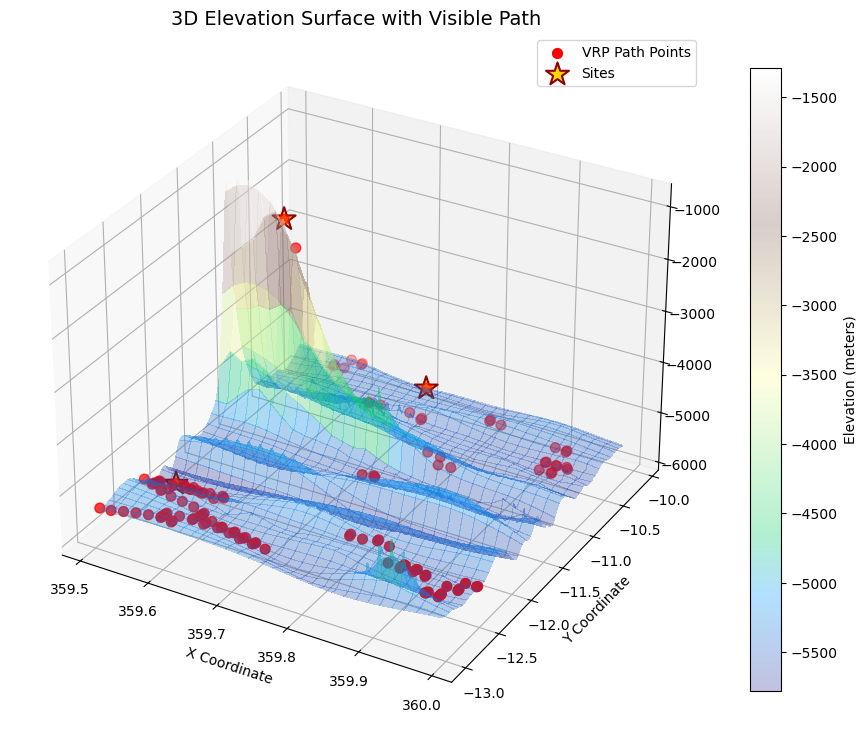

In [4]:
# Assuming you have loaded X, Y, Z, Y_plot, X_plot, and Z_path

# --- Define the offset and apply it ---
Z_OFFSET = 50 # Small offset in meters to lift the path above the surface
Z_path_visible = [z + Z_OFFSET for z in Z_path]
# -------------------------------------

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot the 3D surface
surf = ax.plot_surface(
    X, Y, Z, 
    cmap='terrain', 
    linewidth=0, 
    antialiased=False,
    alpha=0.3 # Sets transparency (0.0 is fully transparent, 1.0 is fully opaque)
)
# Note: You don't need fig.colorbar() for a simple wireframe

fig.colorbar(surf, shrink=0.9, label="Elevation (meters)")

# 2. Plot the path points with the Z-OFFSET
# Use ax.scatter for the points
ax.scatter(
    Y_plot, 
    X_plot, 
    Z_path_visible,  # Use the OFFSET Z-values
    color='red', 
    s=50,            # Marker size for points
    label='VRP Path Points'
)




points_of_interest = [(45, 2), (114, 5), (173, 12)]   # (row, col) pairs (remember: row corresponds to Y index, col to X index)
poi_rows = [p[0] for p in points_of_interest]
poi_cols = [p[1] for p in points_of_interest]

# --- 1. Calculate 3D Coordinates (X, Y, Z) ---
# Map grid indices -> coordinates used for plotting
# Your surface plot used the unconventional order: X-axis = Y-data, Y-axis = X-data

# X-axis of plot (Y Coordinate data)
poi_plot_x = y[poi_rows]
# Y-axis of plot (X Coordinate data)
poi_plot_y = x[poi_cols]

# Z-axis of plot (Elevation)
poi_z = [Z[r, c] for r, c in points_of_interest]

# Apply Z-Offset to ensure visibility (use a value like 200m)

poi_z_visible = [z + Z_OFFSET for z in poi_z]


# --- 2. Add POI to the 3D Map ---
# Get the current 3D axes object
# NOTE: This assumes you are running this code right after fig.add_subplot(111, projection='3d')
# If you are not in the same block, you should use 'ax' (as defined in your earlier code)
# ax = fig.add_subplot(111, projection='3d') 

ax.scatter(
    poi_plot_y,        
    poi_plot_x,        
    poi_z_visible,     
    s=300,            
    c='gold',          
    marker='*',       
    edgecolor='darkred',
    linewidth=1.5,     
    alpha=1.0,         
    zorder=90,        
    label='Sites'
)


ax.set_title("3D Elevation Surface with Visible Path", fontsize=14)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")

# Update legend to reflect both points and line
ax.legend()

plt.show()

In [3]:
with open('vrp_output.txt', 'r') as file:  
    lines = file.readlines()

x_coords = []
y_coords = []
for line in lines:
    line = line.strip()
    values = eval(line)  # This converts the string "(116, 0, 117, 0)" into a tuple (116, 0, 117, 0)
    x_coords.append(values[0])
    y_coords.append(values[1])
#print(Y[0])
X_plot = [y[i] for i in x_coords]
Y_plot = [x[i] for i in y_coords]
Z_path = [Z[row, col] for row, col in zip(x_coords, y_coords)]

print(X_plot,Y_plot)
print(Z_path)


[-12.9304, -10.7283, -10.1547, -10.417, -10.1383, -12.3775, -10.6301, -11.6766, -10.2531, -12.7191, -12.7354, -12.7842, -12.524, -11.1374, -12.3124, -12.9142, -11.2192, -10.2367, -10.1711, -12.3287, -12.5402, -12.7029, -12.7842, -12.5077, -12.9791, -12.9629, -12.7029, -12.2798, -12.8979, -12.4752, -10.712, -12.5402, -10.6301, -12.4589, -12.6053, -10.6137, -10.4826, -10.5973, -10.5645, -10.6628, -12.6704, -10.1383, -12.7517, -12.9466, -12.6216, -12.8492, -12.7354, -12.5565, -12.6704, -12.9304, -12.7842, -12.4426, -12.4589, -12.5402, -11.1374, -12.6866, -12.6704, -12.6378, -12.3775, -10.2531, -12.9466, -12.3775, -12.3938, -12.3775, -10.6464, -10.1547, -12.5728, -12.4426, -12.3287, -12.5077, -12.6866, -12.4426, -11.2355, -10.4662, -12.524, -12.7029, -12.8167, -12.6216, -12.6378, -12.8004, -12.7191, -12.4101, -12.9954, -12.524, -12.5077, -12.8817, -10.417, -10.6464, -12.589, -12.6541, -12.4426, -10.5481, -10.5481, -12.7517, -11.2028, -12.7191, -12.5565, -10.4007, -12.5077, -12.4914, -12.71

In [4]:
ax.plot(
    X_plot, Y_plot, Z_path,
    color='red',
    linewidth=2.5,
    marker='o',
    markersize=4,
    markeredgecolor='black'
)
plt.show()

In [37]:

#fig.colorbar(surf, shrink=0.6, label="Elevation (meters)")
ax.plot(
    X_plot, Y_plot, Z_path,
    color='red',
    linewidth=2.5,
    marker='o',
    markersize=4,
    markeredgecolor='black'
)
points_of_interest = [(38, 10), (66, 8)]

poi_x = [x[c] for (_, c) in points_of_interest]
poi_y = [y[r] for (r, _) in points_of_interest]
poi_z = [Z[r, c] for (r, c) in points_of_interest]

ax.scatter(
    poi_x, poi_y, poi_z,
    s=150,
    c='cyan',
    edgecolor='black',
    marker='*',
    linewidth=0.9
)

for (r, c), px, py, pz in zip(points_of_interest, poi_x, poi_y, poi_z):
    ax.text(px, py, pz + 50, f"({r},{c})", fontsize=9, weight='bold')

# -----------------------
# Final settings + SHOW
# -----------------------
ax.scatter(poi_x, poi_y, poi_z,
           s=150, c='cyan',
           marker='*', edgecolor='black')
ax.set_title("3D Elevation Surface with Rover Path")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")

plt.show()



IndexError: index 60 is out of bounds for axis 0 with size 30